In [2]:
import os

# Search for zip files in Google Drive
for root, dirs, files in os.walk('/drive/MyDrive'):
    for file in files:
        if file.endswith('.zip'):
            print(os.path.join(root, file))

/drive/MyDrive/Lung-data/RP.zip


In [4]:
import os

for root, dirs, files in os.walk('/content/Data'):
    level = root.replace('/content/Data', '').count(os.sep)
    if level <= 4:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')

Data/ (0 files)
  Data/ (0 files)
    test/ (0 files)
      adenocarcinoma/ (120 files)
      normal/ (54 files)
      large.cell.carcinoma/ (51 files)
      squamous.cell.carcinoma/ (90 files)
    train/ (0 files)
      squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/ (155 files)
      normal/ (148 files)
      large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/ (115 files)
      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/ (195 files)
    valid/ (0 files)
      squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/ (15 files)
      normal/ (13 files)
      large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/ (21 files)
      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/ (23 files)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────
TRAIN_DIR = '/content/Data/Data/train'
VALID_DIR = '/content/Data/Data/valid'
TEST_DIR  = '/content/Data/Data/test'
IMG_SIZE  = (224, 224)
BATCH     = 32

# ── Data Generators ────────────────────────────────────
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    class_mode='categorical', batch_size=BATCH,
    shuffle=False
)

valid_gen = valid_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE,
    class_mode='categorical', batch_size=BATCH,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    class_mode='categorical', batch_size=BATCH,
    shuffle=False
)

print("Train classes:", train_gen.class_indices)
print("Test classes:", test_gen.class_indices)
print(f"Train samples: {train_gen.samples}")
print(f"Valid samples: {valid_gen.samples}")
print(f"Test samples:  {test_gen.samples}")

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Train classes: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
Test classes: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}
Train samples: 613
Valid samples: 72
Test samples:  315


In [6]:
# ── VGG19 Feature Extractor ────────────────────────────
print("Loading VGG19 model...")

base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Use GlobalAveragePooling to extract features
feature_extractor = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)

# Freeze all layers - we only use VGG19 as feature extractor
for layer in base_model.layers:
    layer.trainable = False

print("VGG19 loaded successfully")
print(f"Feature vector size: {feature_extractor.output_shape[1]}")

# ── Extract Features ───────────────────────────────────
def extract_features(generator, model):
    generator.reset()
    features = []
    labels = []
    steps = len(generator)

    for i in range(steps):
        batch_images, batch_labels = next(generator)
        batch_features = model.predict(batch_images, verbose=0)
        features.append(batch_features)
        labels.append(batch_labels)
        print(f"  Step {i+1}/{steps} done", end='\r')

    features = np.vstack(features)
    labels = np.vstack(labels)
    labels = np.argmax(labels, axis=1)
    return features, labels

print("\nExtracting train features...")
X_train, y_train = extract_features(train_gen, feature_extractor)

print("\nExtracting valid features...")
X_valid, y_valid = extract_features(valid_gen, feature_extractor)

print("\nExtracting test features...")
X_test, y_test = extract_features(test_gen, feature_extractor)

print(f"\nFeature extraction complete")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Loading VGG19 model...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG19 loaded successfully
Feature vector size: 512

Extracting train features...
  Step 20/20 done
Extracting valid features...
  Step 3/3 done
Extracting test features...
  Step 10/10 done
Feature extraction complete
X_train shape: (613, 512)
X_test shape:  (315, 512)


In [7]:
# ── Train SVM ──────────────────────────────────────────
print("Training SVM...")
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
svm_model.fit(X_train, y_train)
print("SVM training complete")

# ── Train Random Forest ────────────────────────────────
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest training complete")

# ── Evaluate Both Models ───────────────────────────────
class_names = ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']

def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*50}")
    print(f"Results: {model_name}")
    print('='*50)

    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    return y_pred, acc, prec, rec, f1

svm_pred,  svm_acc,  svm_prec,  svm_rec,  svm_f1  = evaluate_model(svm_model,  X_test, y_test, "VGG19 + SVM")
rf_pred,   rf_acc,   rf_prec,   rf_rec,   rf_f1   = evaluate_model(rf_model,   X_test, y_test, "VGG19 + Random Forest")

Training SVM...
SVM training complete

Training Random Forest...
Random Forest training complete

Results: VGG19 + SVM
Accuracy  : 0.8127
Precision : 0.8198
Recall    : 0.8127
F1 Score  : 0.8124

Classification Report:
                         precision    recall  f1-score   support

         Adenocarcinoma       0.73      0.85      0.79       120
   Large Cell Carcinoma       0.78      0.75      0.76        51
                 Normal       1.00      0.98      0.99        54
Squamous Cell Carcinoma       0.85      0.70      0.77        90

               accuracy                           0.81       315
              macro avg       0.84      0.82      0.83       315
           weighted avg       0.82      0.81      0.81       315


Results: VGG19 + Random Forest
Accuracy  : 0.7270
Precision : 0.7316
Recall    : 0.7270
F1 Score  : 0.7254

Classification Report:
                         precision    recall  f1-score   support

         Adenocarcinoma       0.65      0.77      0.70      

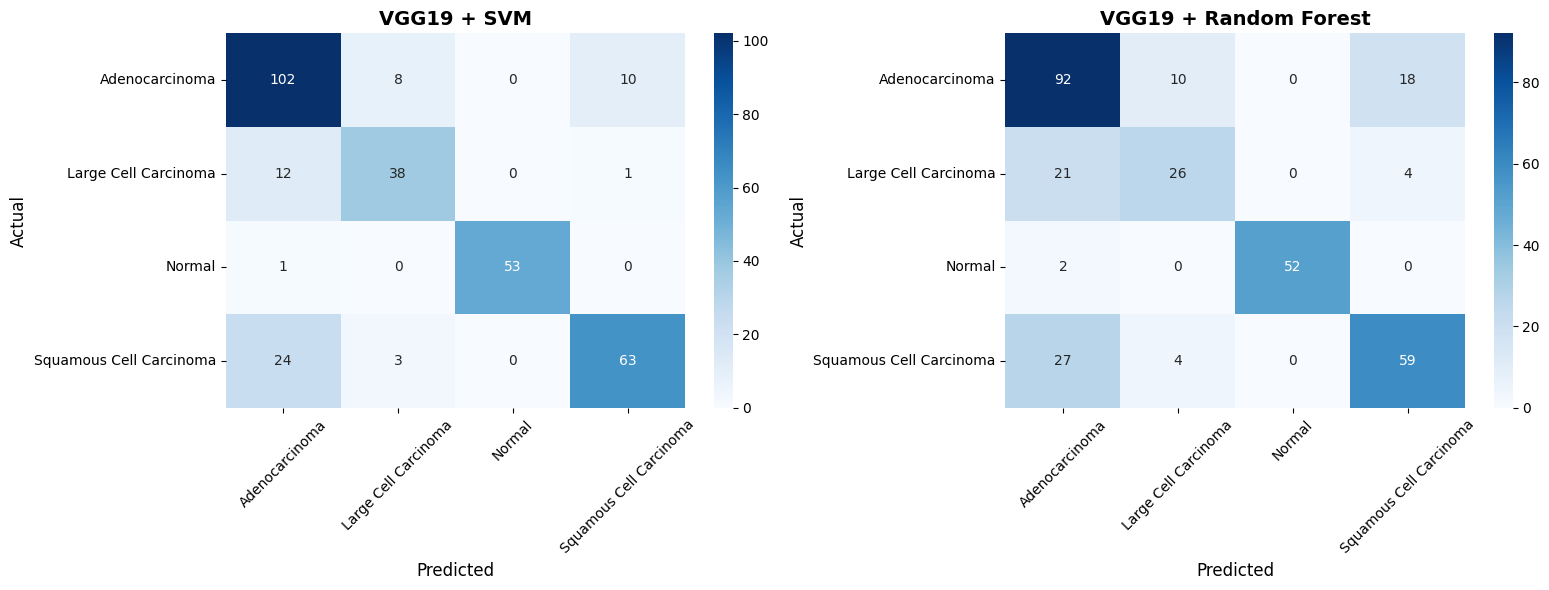

Confusion matrices saved


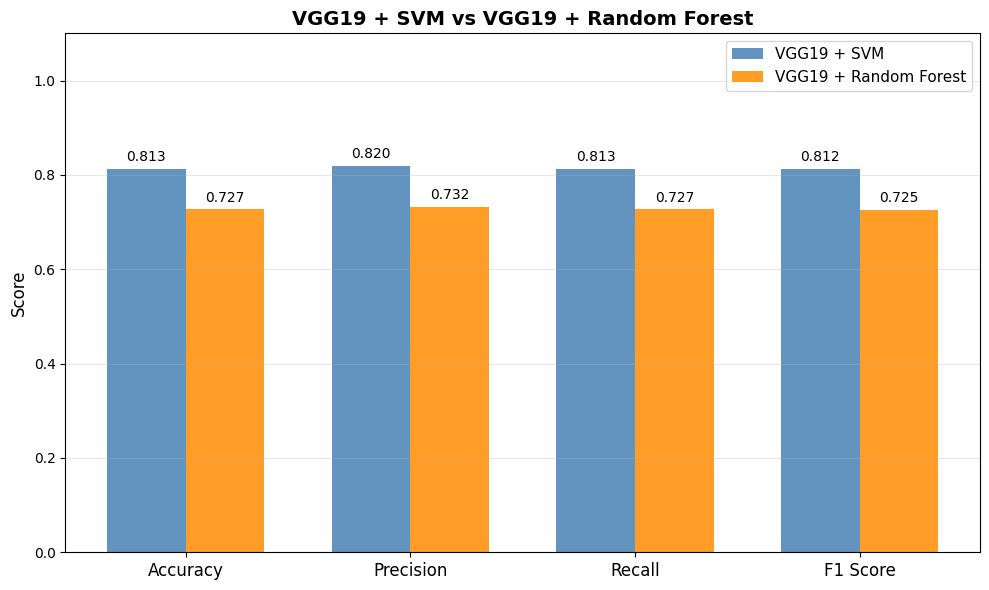

Comparison chart saved

Model                        Acc   Prec    Rec     F1
VGG19 + SVM               0.8127 0.8198 0.8127 0.8124
VGG19 + Random Forest     0.7270 0.7316 0.7270 0.7254

Best Model: VGG19 + SVM
Accuracy improvement: 0.0857


In [8]:
# ── Confusion Matrices ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_confusion_matrix(ax, y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plot_confusion_matrix(axes[0], y_test, svm_pred,
                      'VGG19 + SVM', class_names)
plot_confusion_matrix(axes[1], y_test, rf_pred,
                      'VGG19 + Random Forest', class_names)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved")

# ── Model Comparison Bar Chart ─────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
svm_scores = [svm_acc, svm_prec, svm_rec, svm_f1]
rf_scores  = [rf_acc,  rf_prec,  rf_rec,  rf_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, svm_scores, width,
               label='VGG19 + SVM', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_scores,  width,
               label='VGG19 + Random Forest', color='darkorange', alpha=0.85)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('VGG19 + SVM vs VGG19 + Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved")

# ── Summary Table ──────────────────────────────────────
print("\n" + "="*55)
print(f"{'Model':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("="*55)
print(f"{'VGG19 + SVM':<25} {svm_acc:>6.4f} {svm_prec:>6.4f} {svm_rec:>6.4f} {svm_f1:>6.4f}")
print(f"{'VGG19 + Random Forest':<25} {rf_acc:>6.4f} {rf_prec:>6.4f} {rf_rec:>6.4f} {rf_f1:>6.4f}")
print("="*55)
print(f"\nBest Model: {'VGG19 + SVM' if svm_acc > rf_acc else 'VGG19 + Random Forest'}")
print(f"Accuracy improvement: {abs(svm_acc - rf_acc):.4f}")

In [9]:
import pickle
import json

# ── Save SVM and Random Forest models ─────────────────
with open('vgg19_svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("SVM model saved")

with open('vgg19_rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("Random Forest model saved")

# ── Save results to JSON ───────────────────────────────
results = {
    'VGG19_SVM': {
        'accuracy': round(svm_acc, 4),
        'precision': round(svm_prec, 4),
        'recall': round(svm_rec, 4),
        'f1_score': round(svm_f1, 4)
    },
    'VGG19_RandomForest': {
        'accuracy': round(rf_acc, 4),
        'precision': round(rf_prec, 4),
        'recall': round(rf_rec, 4),
        'f1_score': round(rf_f1, 4)
    },
    'best_model': 'VGG19 + SVM',
    'accuracy_improvement': round(abs(svm_acc - rf_acc), 4)
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved to results.json")

print("\nFiles ready to upload:")
print("- vgg19_svm_model.pkl")
print("- vgg19_rf_model.pkl")
print("- results.json")
print("- confusion_matrices.png")
print("- model_comparison.png")


SVM model saved
Random Forest model saved
Results saved to results.json

Files ready to upload:
- vgg19_svm_model.pkl
- vgg19_rf_model.pkl
- results.json
- confusion_matrices.png
- model_comparison.png


Upload a CT scan image:


Saving 000108 (3).png to 000108 (3).png

Analyzing: 000108 (3).png


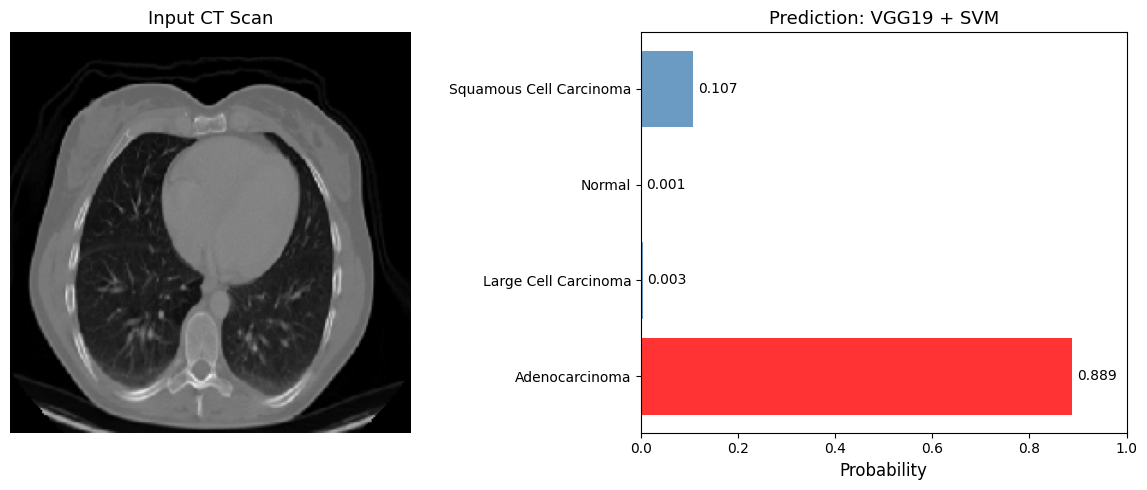


LUNG CANCER DETECTION REPORT
Model Used     : VGG19 + SVM
Diagnosis      : Adenocarcinoma
Confidence     : 88.86%
Result: Cancer detected — Adenocarcinoma
Recommendation: Please consult a medical professional immediately


In [10]:
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np

def predict_lung_cancer(img_path, model_type='svm'):
    """
    Predict lung cancer type from a CT scan image
    model_type: 'svm' or 'rf'
    """
    class_names = [
        'Adenocarcinoma',
        'Large Cell Carcinoma',
        'Normal',
        'Squamous Cell Carcinoma'
    ]

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Extract features using VGG19
    features = feature_extractor.predict(img_array, verbose=0)

    # Predict using selected model
    if model_type == 'svm':
        prediction = svm_model.predict(features)[0]
        probabilities = svm_model.predict_proba(features)[0]
        model_name = "VGG19 + SVM"
    else:
        prediction = rf_model.predict(features)[0]
        probabilities = rf_model.predict_proba(features)[0]
        model_name = "VGG19 + Random Forest"

    # Display results
    plt.figure(figsize=(12, 5))

    # Show image
    plt.subplot(1, 2, 1)
    img_display = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img_display)
    plt.axis('off')
    plt.title('Input CT Scan', fontsize=13)

    # Show probabilities
    plt.subplot(1, 2, 2)
    colors = ['red' if i == prediction else 'steelblue' for i in range(4)]
    bars = plt.barh(class_names, probabilities, color=colors, alpha=0.8)
    plt.xlabel('Probability', fontsize=12)
    plt.title(f'Prediction: {model_name}', fontsize=13)
    plt.xlim(0, 1)

    # Add probability labels
    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{prob:.3f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print diagnosis
    print("\n" + "="*50)
    print("LUNG CANCER DETECTION REPORT")
    print("="*50)
    print(f"Model Used     : {model_name}")
    print(f"Diagnosis      : {class_names[prediction]}")
    print(f"Confidence     : {probabilities[prediction]*100:.2f}%")
    print("="*50)

    if class_names[prediction] == 'Normal':
        print("Result: No cancer detected")
    else:
        print(f"Result: Cancer detected — {class_names[prediction]}")
        print("Recommendation: Please consult a medical professional immediately")
    print("="*50)


# Upload an image and predict
print("Upload a CT scan image:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nAnalyzing: {filename}")
    predict_lung_cancer(filename, model_type='svm')

Upload a CT scan image:


Saving 000108 (3).png to 000108 (3) (1).png

Analyzing with Random Forest: 000108 (3) (1).png


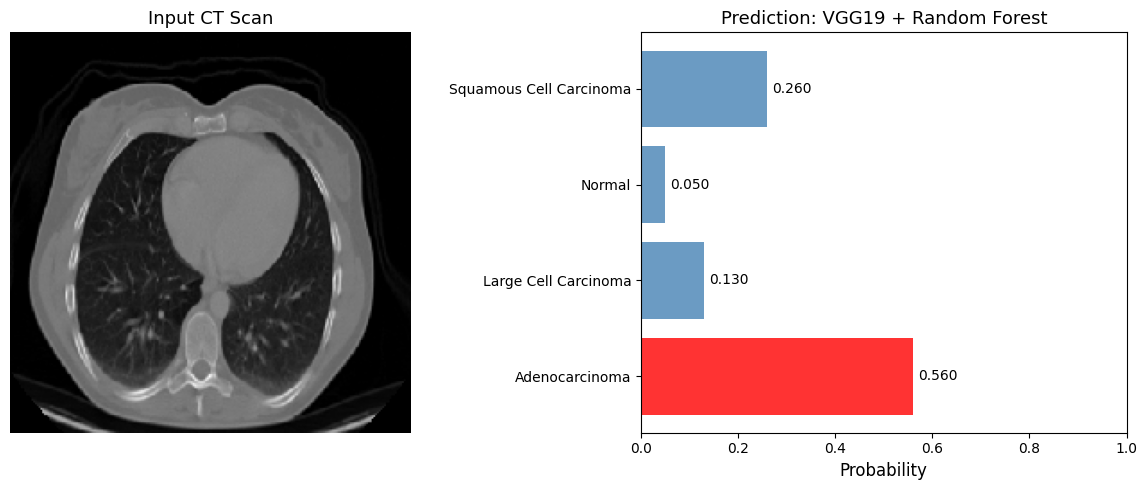


LUNG CANCER DETECTION REPORT
Model Used     : VGG19 + Random Forest
Diagnosis      : Adenocarcinoma
Confidence     : 56.00%
Result: Cancer detected — Adenocarcinoma
Recommendation: Please consult a medical professional immediately


In [11]:
print("Upload a CT scan image:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nAnalyzing with Random Forest: {filename}")
    predict_lung_cancer(filename, model_type='rf')

In [12]:
readme = """# Lung Cancer Detection using VGG19

Deep learning project for lung cancer classification using VGG19
as a feature extractor combined with traditional ML classifiers.

## Problem Statement

Lung cancer is one of the leading causes of cancer-related deaths globally.
Early and accurate detection is critical for improving survival rates.
This project uses transfer learning with VGG19 to extract features from
CT scan images and classifies them using SVM and Random Forest.

## Dataset

IQ-OTH/NCCD Lung Cancer Dataset
- 613 training images
- 72 validation images
- 315 test images
- 4 classes: Adenocarcinoma, Large Cell Carcinoma, Normal, Squamous Cell Carcinoma

## Methodology

    CT Scan Images
          Down
    VGG19 Feature Extraction (512 features)
          Down
    Traditional ML Classifiers
       SVM        Random Forest

## Results

| Model                 | Accuracy | Precision | Recall | F1 Score |
|-----------------------|----------|-----------|--------|----------|
| VGG19 + SVM           | 81.27%   | 81.98%    | 81.27% | 81.24%   |
| VGG19 + Random Forest | 72.70%   | 73.16%    | 72.70% | 72.54%   |

VGG19 + SVM outperforms Random Forest by 8.57% in accuracy.

## Key Findings

- Normal class achieved near perfect classification (99% F1) with SVM
- SVM consistently outperforms Random Forest across all metrics
- VGG19 ImageNet features transfer well to medical imaging
- Adenocarcinoma was the most challenging class to classify

## Prediction Output

The model takes a single CT scan image as input and outputs:
- Predicted cancer type
- Confidence score for each class
- Visual probability bar chart
- Diagnosis recommendation

## Tech Stack

- Python 3.12
- TensorFlow / Keras — VGG19 feature extraction
- Scikit-learn — SVM and Random Forest classifiers
- Matplotlib / Seaborn — visualizations
- Google Colab — development environment

## Setup

Install dependencies:
    pip install tensorflow scikit-learn numpy matplotlib seaborn

## Usage

1. Upload dataset to Google Drive
2. Open lung_cancer_detection.ipynb in Google Colab
3. Mount Google Drive and update dataset path
4. Run all cells
5. Upload a CT scan image when prompted for prediction

## Project Structure

    lung-cancer-detection-vgg19/
    ├── lung_cancer_detection.ipynb
    ├── results.json
    ├── confusion_matrices.png
    ├── model_comparison.png
    └── README.md

## Author

Harsha — Masters in Computer Science
github.com/Harsha123v
"""

with open('/content/README.md', 'w') as f:
    f.write(readme)

print("README.md created successfully")
print("Download it from the left files panel")

README.md created successfully
Download it from the left files panel
